# Reto de Clustering: Segmentación de Perfiles de Usuario

## Escenario: Aprendizaje No Supervisado

Los datos de comportamiento de usuarios de este e-commerce no tienen etiquetas de segmento. El objetivo es descubrir grupos naturales de sesiones para que marketing personalice sus estrategias según comportamientos reales.

**Dataset:** *Online Shoppers Purchasing Intention* — 12,330 sesiones de navegación, con variables de comportamiento (páginas vistas, duración, rebote, salida, valor de página) y de contexto (visitante, mes, fin de semana, si hubo compra).

**Estructura:**
- Fase 1 — EDA y pipeline de preprocesamiento (imputación, escalado, PCA/UMAP)
- Fase 2 — Modelado (K-Means, DBSCAN, GMM) y pipeline final de producción
- Fase 3 — Perfilamiento de negocio


In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'


In [2]:
import os

RUTA_LOCAL = "ecommerce_shopper_intention.csv"
URL_RESPALDO = (
    "https://raw.githubusercontent.com/Camille-Le-Roy/"
    "data_analytics_resources/main/"
    "Module_02_machine_learning_and_feature_engineering/"
    "datasets/online_shoppers_intention.csv"
)

if os.path.exists(RUTA_LOCAL):
    df = pd.read_csv(RUTA_LOCAL)
    print(f"Datos cargados desde archivo local: {RUTA_LOCAL}")
else:
    df = pd.read_csv(URL_RESPALDO)
    print("Archivo local no encontrado. Datos cargados desde el respaldo remoto:")
    print(URL_RESPALDO)

print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()


Archivo local no encontrado. Datos cargados desde el respaldo remoto:
https://raw.githubusercontent.com/Camille-Le-Roy/data_analytics_resources/main/Module_02_machine_learning_and_feature_engineering/datasets/online_shoppers_intention.csv
Filas: 12,330 | Columnas: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## Fase 1: EDA y Pipeline de Ingeniería

### Paso 1: Exploración — nulos y distribuciones


In [4]:
nulos = df.isnull().sum()
if nulos.sum() == 0:
    print("No se encontraron valores nulos en el dataset.")
else:
    print("Valores nulos por columna:")
    print(nulos[nulos > 0])

df.describe().T


No se encontraron valores nulos en el dataset.


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


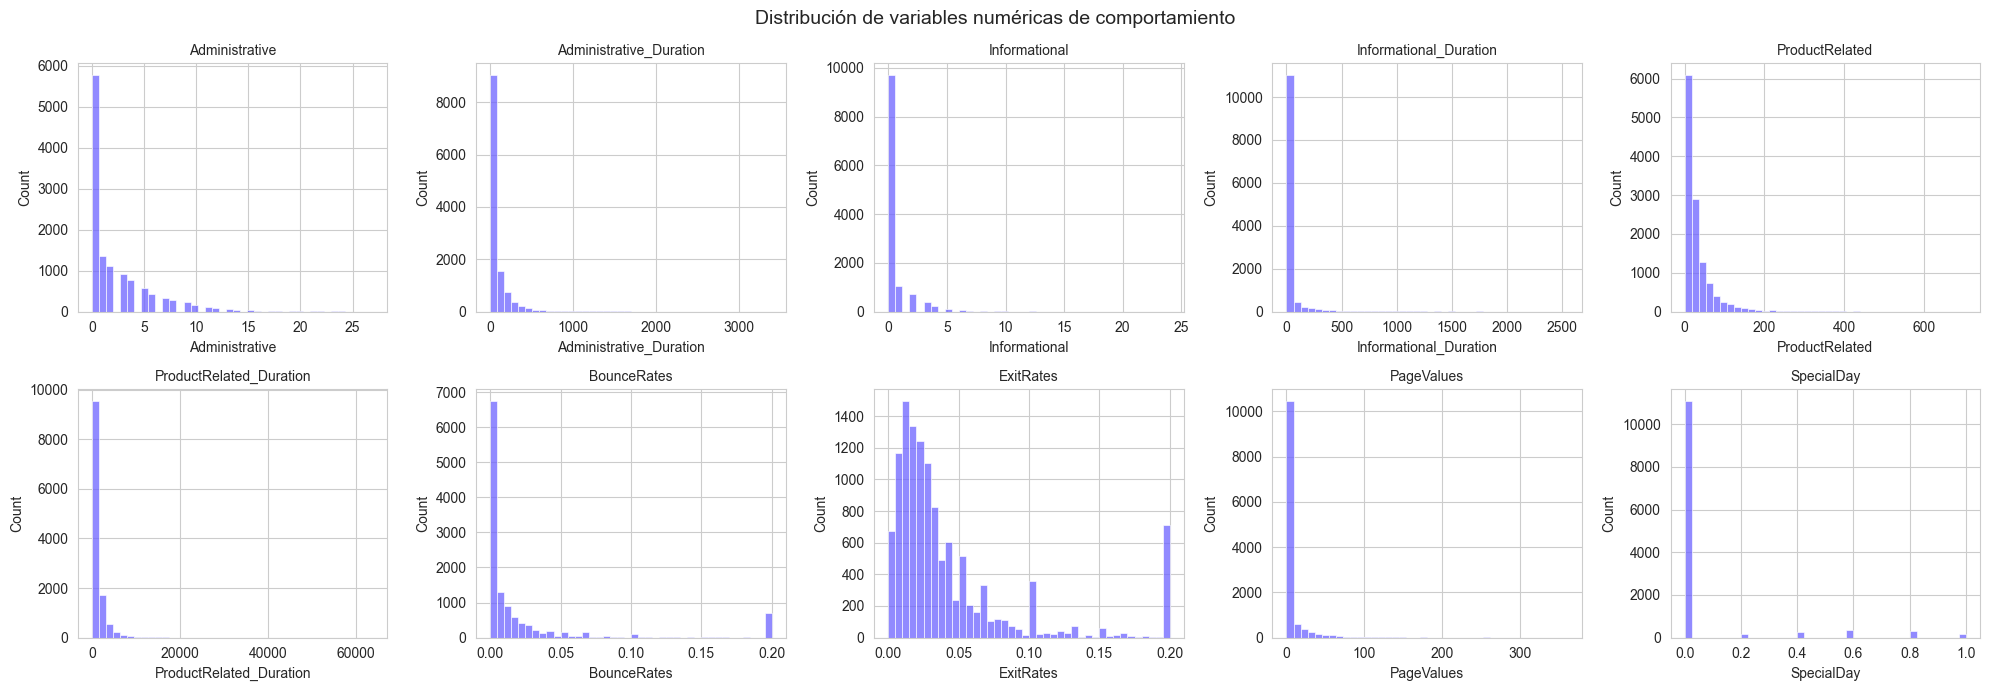

In [5]:
numeric_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
                'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], bins=40, ax=ax, color='#6C63FF')
    ax.set_title(col, fontsize=10)
plt.suptitle('Distribución de variables numéricas de comportamiento', fontsize=14)
plt.tight_layout()
plt.show()


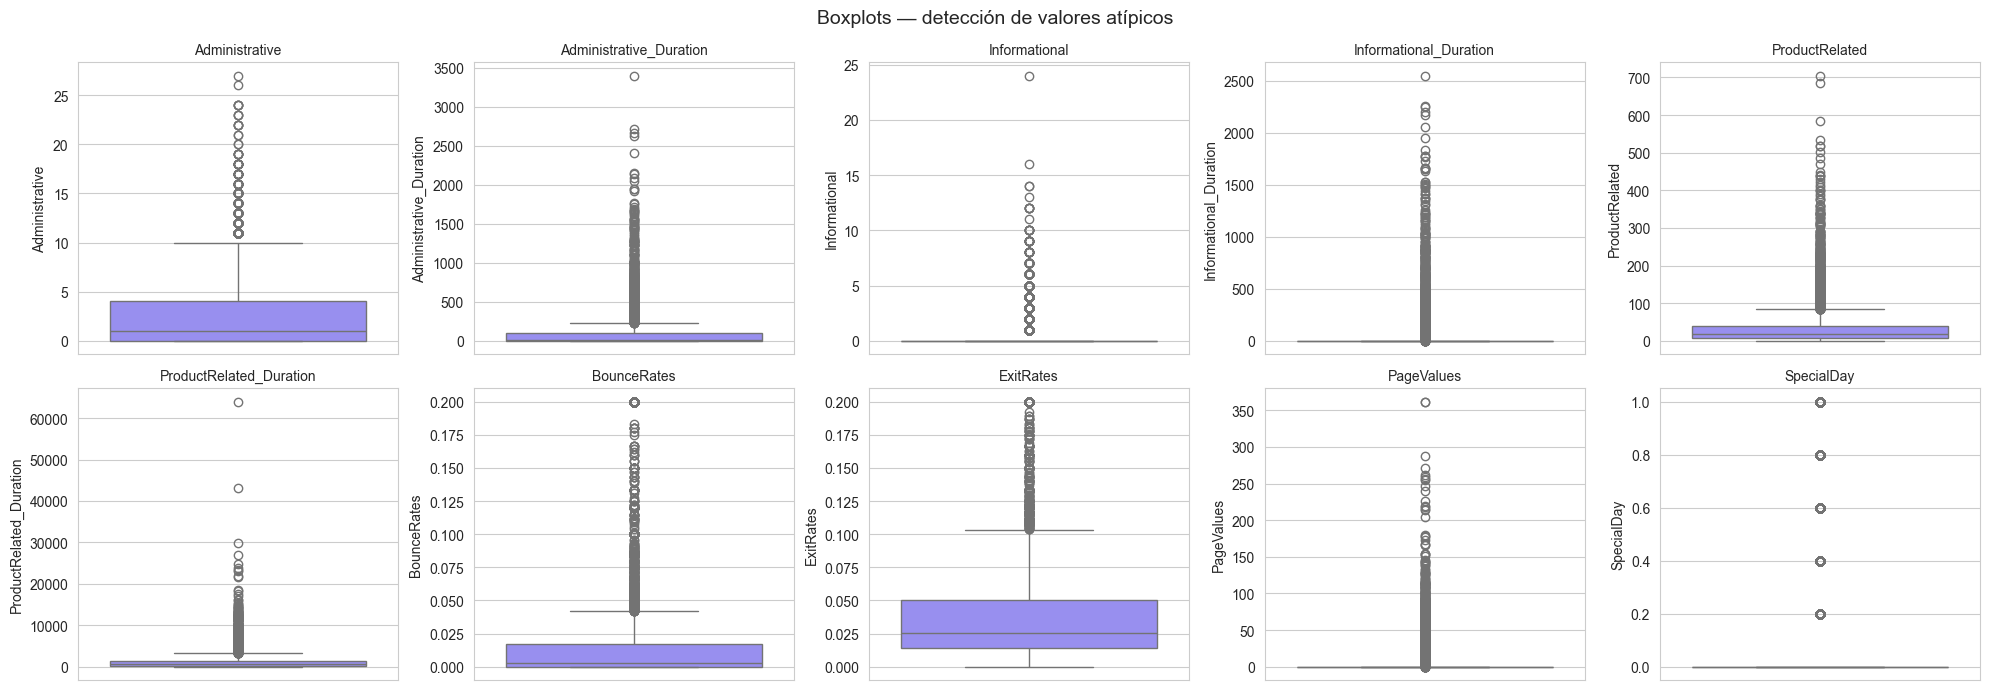

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='#8B7FFF')
    ax.set_title(col, fontsize=10)
plt.suptitle('Boxplots — detección de valores atípicos', fontsize=14)
plt.tight_layout()
plt.show()


**Lectura:** las variables de comportamiento están sesgadas a la derecha (la mayoría de sesiones son cortas) y en escalas muy distintas (duraciones hasta ~64,000 segundos vs. tasas entre 0 y 0.2). El escalado es indispensable para cualquier algoritmo de distancia. Los valores extremos no son errores: son sesiones de usuarios muy comprometidos, justo el segmento que le interesa al negocio.

### Variables categóricas


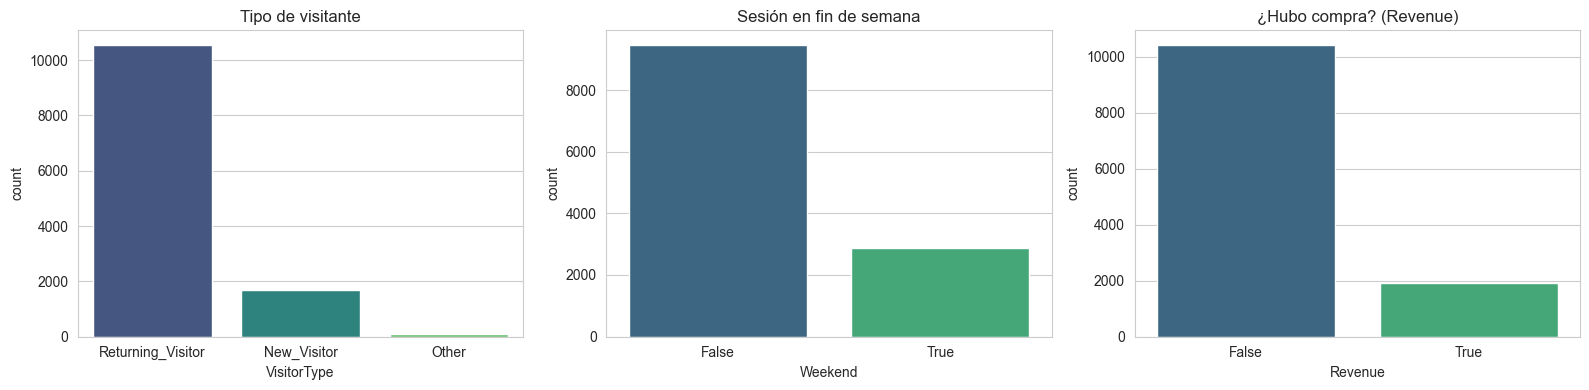

Tasa de conversión global del sitio: 15.47%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(x='VisitorType', data=df, ax=axes[0], hue='VisitorType', palette='viridis', legend=False)
sns.countplot(x='Weekend', data=df, ax=axes[1], hue='Weekend', palette='viridis', legend=False)
sns.countplot(x='Revenue', data=df, ax=axes[2], hue='Revenue', palette='viridis', legend=False)
axes[0].set_title('Tipo de visitante')
axes[1].set_title('Sesión en fin de semana')
axes[2].set_title('¿Hubo compra? (Revenue)')
plt.tight_layout()
plt.show()

print(f"Tasa de conversión global del sitio: {df['Revenue'].mean():.2%}")


### Paso 2: Pipeline de Preprocesamiento (Imputación + Escalado)

Para segmentar uso variables numéricas de comportamiento (páginas y duración administrativas/informativas/de producto, tasas de rebote/salida, valor de página, proximidad a fecha especial) y dos categóricas de contexto: `VisitorType` y `Weekend`.

`Revenue` queda fuera del entrenamiento porque es la variable objetivo del dataset original; usarla causaría data leakage, así que se reserva para validar los perfiles en la Fase 3. También excluyo `Month`, `OperatingSystems`, `Browser`, `Region` y `TrafficType`: son códigos técnicos sin una escala de comportamiento clara (queda como mejora futura).

El pipeline incluye imputación aunque el dataset no tiene nulos, para que siga funcionando si llegan datos nuevos con valores faltantes.


In [8]:
df_model = df.copy()
df_model['Weekend'] = df_model['Weekend'].astype(str)
df_model['VisitorType'] = df_model['VisitorType'].astype(str)

categorical_cols = ['VisitorType', 'Weekend']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_cols)
])

X_processed = preprocessor.fit_transform(df_model)
X_processed = np.asarray(X_processed.todense()) if hasattr(X_processed, 'todense') else X_processed
print(f"Forma de la matriz preprocesada (numéricas escaladas + categóricas one-hot): {X_processed.shape}")


Forma de la matriz preprocesada (numéricas escaladas + categóricas one-hot): (12330, 15)


### Paso 3: Reducción de Dimensionalidad (PCA y UMAP)


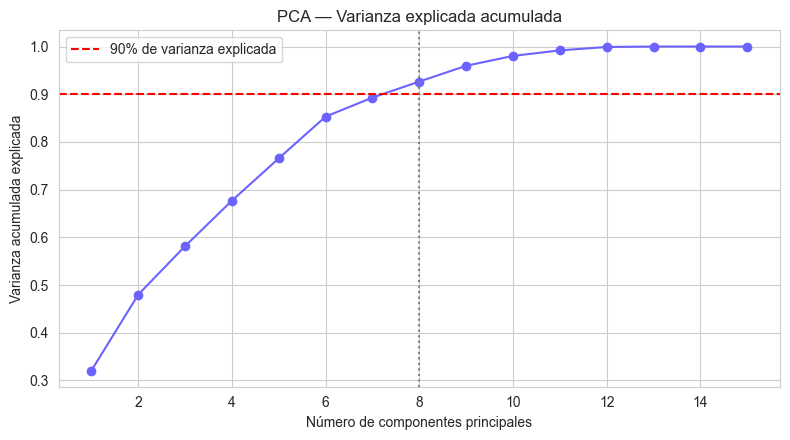

Componentes necesarios para retener ≥90% de varianza: 8 (92.65%)


In [9]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_processed)
var_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)
n_components_90 = int(np.argmax(cum_var >= 0.90) + 1)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', color='#6C63FF')
plt.axhline(0.90, color='red', linestyle='--', label='90% de varianza explicada')
plt.axvline(n_components_90, color='gray', linestyle=':')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza acumulada explicada')
plt.title('PCA — Varianza explicada acumulada')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Componentes necesarios para retener ≥90% de varianza: {n_components_90} ({cum_var[n_components_90 - 1]:.2%})")


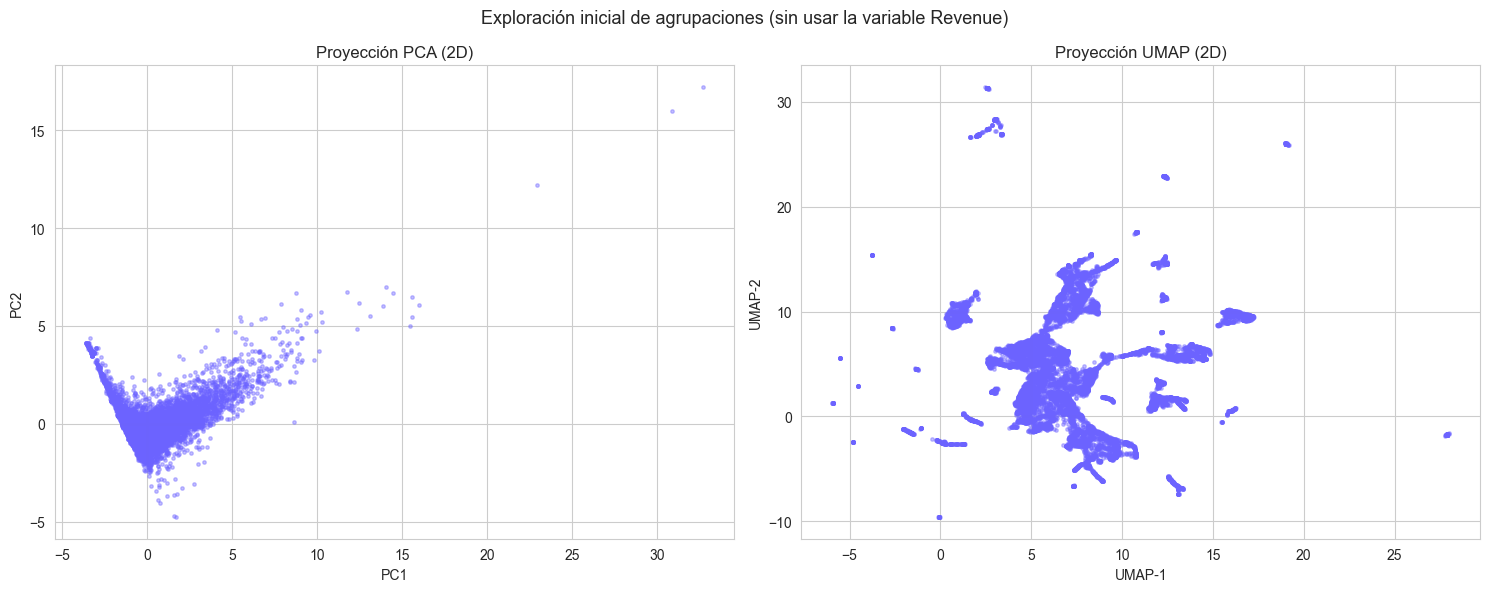

In [10]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_processed)

reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE, n_neighbors=30, min_dist=0.1)
umap_2d = reducer.fit_transform(X_processed)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], s=6, alpha=0.4, color='#6C63FF')
axes[0].set_title('Proyección PCA (2D)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

axes[1].scatter(umap_2d[:, 0], umap_2d[:, 1], s=6, alpha=0.4, color='#6C63FF')
axes[1].set_title('Proyección UMAP (2D)')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')

plt.suptitle('Exploración inicial de agrupaciones (sin usar la variable Revenue)', fontsize=13)
plt.tight_layout()
plt.show()


**Lectura:** en ambas proyecciones ya se ve una masa densa de sesiones "normales" y una cola de sesiones con más engagement, sin haber usado ninguna etiqueta. Hay estructura de grupos que los algoritmos pueden aprovechar. `Revenue` (si hubo compra) queda fuera de esta exploración y del entrenamiento; se usa solo en la Fase 3 para validar si los clústeres corresponden a comportamientos de compra distintos.


## Fase 2: Modelado y Validación Matemática

### Entrenamiento y Comparación de Modelos

Modelo con el espacio reducido por PCA (≥90% de varianza) en vez del espacio original de alta dimensión, para mitigar la "maldición de la dimensionalidad" en las métricas de distancia (clave para K-Means y DBSCAN) sin perder señal. La proyección en 2 componentes (`pca_2d`) es solo para graficar.


In [11]:
X_model = PCA(n_components=n_components_90, random_state=RANDOM_STATE).fit_transform(X_processed)
print(f"Espacio de modelado: {X_model.shape[1]} componentes principales ({cum_var[n_components_90 - 1]:.1%} de varianza retenida)")


Espacio de modelado: 8 componentes principales (92.7% de varianza retenida)


#### K-Means — Método del Codo y Coeficiente de Silueta


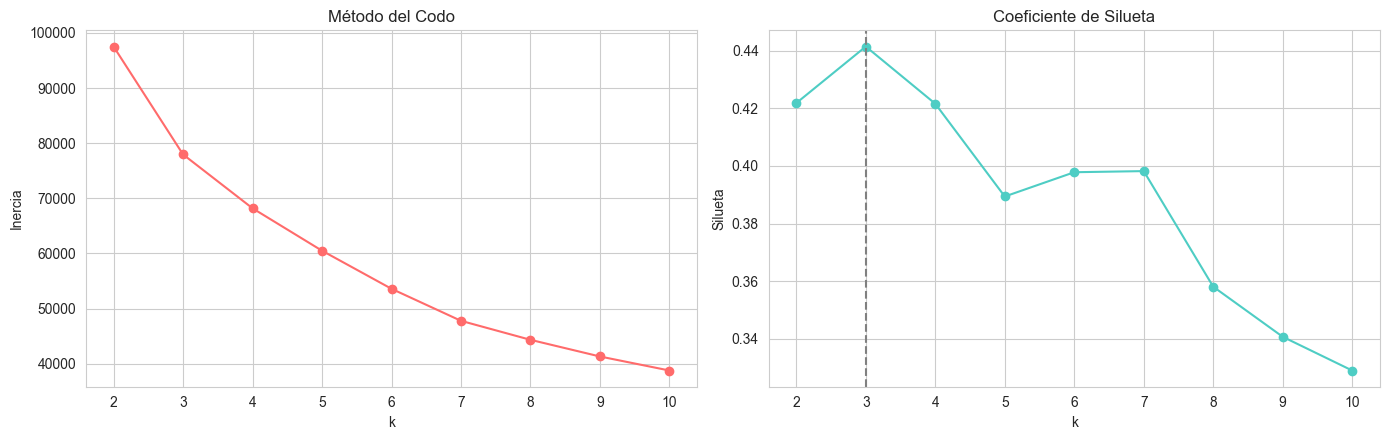

k óptimo según silueta: 3 (silueta = 0.4415)


In [12]:
K_range = range(2, 11)
inertias, silhouettes = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_model)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_model, km.labels_, sample_size=5000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(list(K_range), inertias, marker='o', color='#FF6B6B')
axes[0].set_title('Método del Codo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')

axes[1].plot(list(K_range), silhouettes, marker='o', color='#4ECDC4')
best_k = list(K_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color='gray', linestyle='--')
axes[1].set_title('Coeficiente de Silueta'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silueta')
plt.tight_layout()
plt.show()

print(f"k óptimo según silueta: {best_k} (silueta = {max(silhouettes):.4f})")


**Justificación de k:** la inercia (codo) desciende de forma suave sin un quiebre único y evidente, así que el criterio decisivo es el **coeficiente de silueta**, que alcanza su máximo en **k=3** (≈0.44). Valores de k mayores generan grupos más pequeños y con menor separación (silueta decreciente), por lo que k=3 ofrece el mejor balance entre cohesión, separación e interpretabilidad de negocio.


In [13]:
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X_model)
labels_kmeans = kmeans_final.labels_
sil_kmeans = silhouette_score(X_model, labels_kmeans, sample_size=5000, random_state=RANDOM_STATE)
print(f"K-Means final -> k={best_k} | silueta={sil_kmeans:.4f}")
print(pd.Series(labels_kmeans).value_counts().sort_index().rename('tamaño del clúster'))


K-Means final -> k=3 | silueta=0.4415
0    1624
1    9653
2    1053
Name: tamaño del clúster, dtype: int64


#### DBSCAN — Selección de `eps` y `min_samples`

Se usa la heurística `min_samples = 2 × n_dimensiones` (Sander et al.) y el gráfico de k-distancias para orientar la elección de `eps`.


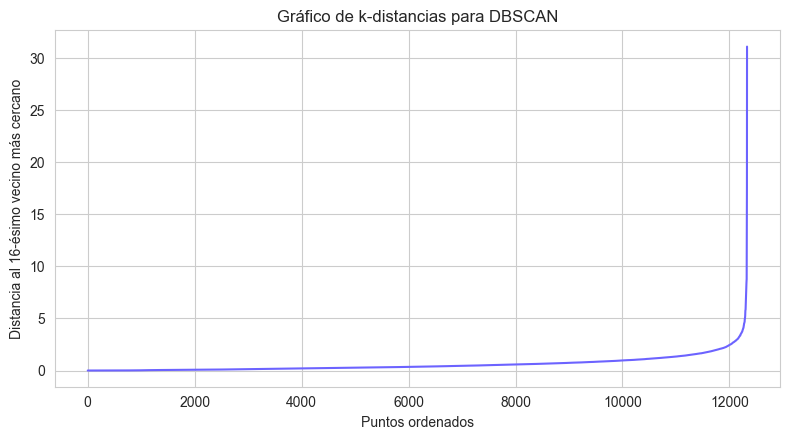

In [14]:
min_samples = 2 * X_model.shape[1]
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_model)
distances, _ = nn.kneighbors(X_model)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4.5))
plt.plot(k_distances, color='#6C63FF')
plt.xlabel('Puntos ordenados'); plt.ylabel(f'Distancia al {min_samples}-ésimo vecino más cercano')
plt.title('Gráfico de k-distancias para DBSCAN')
plt.tight_layout()
plt.show()


El "codo" del gráfico de k-distancias cae en una zona de `eps` muy alto, que agrupa todo el dataset en un solo clúster (la densidad es muy heterogénea: hay una masa enorme de sesiones cortas y homogéneas). Por eso complemento el análisis con una búsqueda en cuadrícula de `eps`, evaluando cuántos clústeres produce cada valor y su silueta.


In [15]:
eps_grid = [0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
resultados = []
for eps in eps_grid:
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X_model)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).mean() * 100
    if n_clusters > 1:
        mask = labels != -1
        sil = silhouette_score(X_model[mask], labels[mask], sample_size=min(5000, mask.sum()), random_state=RANDOM_STATE)
    else:
        sil = np.nan
    resultados.append((eps, n_clusters, round(noise_pct, 2), sil))

grid_df = pd.DataFrame(resultados, columns=['eps', 'n_clústeres', '% ruido', 'silueta'])
grid_df


,eps,n_clústeres,% ruido,silueta
0,0.7,11,22.01,-0.037662
1,0.8,12,17.93,-0.028540
2,0.9,10,14.94,-0.104617
3,1.0,3,12.30,0.435814
4,1.1,2,10.35,0.466902
5,1.2,2,8.68,0.453735
6,1.3,1,7.23,NaN


**Elección final:** `eps=1.0`, `min_samples=16` da 3 clústeres con silueta ≈0.44 (sin ruido), muy cerca de K-Means, y deja ~12% de sesiones como ruido. `eps=1.1` tiene silueta algo mayor (0.467), pero colapsa a solo 2 clústeres, perdiendo el grupo minoritario y la comparación directa con K-Means (k=3). Prioricé `eps=1.0` para mantener 3 segmentos comparables, aun con silueta un poco menor. Valores mayores de `eps` colapsan todo en un clúster gigante; valores menores fragmentan en microclústeres.


In [16]:
eps_final = 1.0
min_samples_final = min_samples
dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final).fit(X_model)
labels_dbscan = dbscan_final.labels_
n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
mask_db = labels_dbscan != -1
sil_dbscan = silhouette_score(X_model[mask_db], labels_dbscan[mask_db], sample_size=5000, random_state=RANDOM_STATE)

print(f"DBSCAN final -> eps={eps_final} | min_samples={min_samples_final}")
print(f"Clústeres encontrados: {n_clusters_db} | Ruido: {(labels_dbscan == -1).mean():.2%} | Silueta (sin ruido): {sil_dbscan:.4f}")
print(pd.Series(labels_dbscan).value_counts().sort_index().rename('tamaño (−1 = ruido)'))


DBSCAN final -> eps=1.0 | min_samples=16
Clústeres encontrados: 3 | Ruido: 12.30% | Silueta (sin ruido): 0.4358
-1     1517
 0    10684
 1      110
 2       19
Name: tamaño (−1 = ruido), dtype: int64


#### Gaussian Mixture Models (GMM) — BIC / AIC


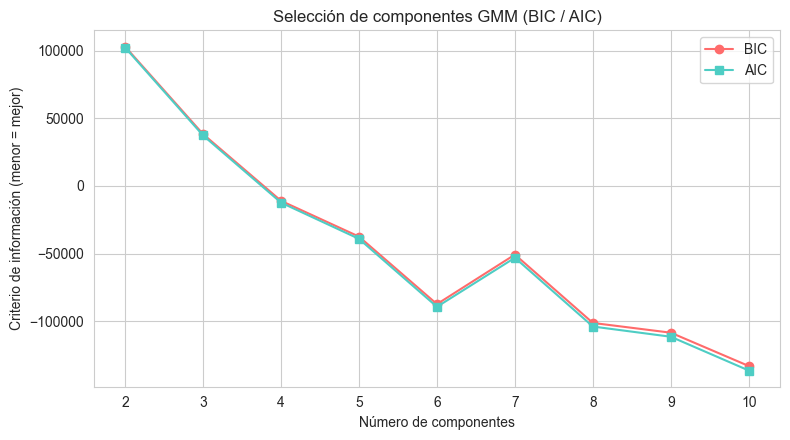

In [17]:
Ks_gmm = range(2, 11)
bics, aics = [], []
for k in Ks_gmm:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=3).fit(X_model)
    bics.append(gmm.bic(X_model))
    aics.append(gmm.aic(X_model))

plt.figure(figsize=(8, 4.5))
plt.plot(list(Ks_gmm), bics, marker='o', label='BIC', color='#FF6B6B')
plt.plot(list(Ks_gmm), aics, marker='s', label='AIC', color='#4ECDC4')
plt.xlabel('Número de componentes'); plt.ylabel('Criterio de información (menor = mejor)')
plt.title('Selección de componentes GMM (BIC / AIC)')
plt.legend()
plt.tight_layout()
plt.show()


**Nota:** BIC y AIC bajan de forma monótona en todo el rango probado (2 a 10 componentes), sin mínimo claro. No es sobreajuste clásico (no hay un conjunto de prueba que empeore): BIC/AIC miden qué tan bien la mezcla de gaussianas ajusta la densidad general, y una densidad tan compleja admite mejoras de verosimilitud casi indefinidas al sumar componentes, aunque esas particiones ya no sirvan como segmentos de negocio. Por eso contrasto con el coeficiente de silueta, que sí mide separación entre grupos.


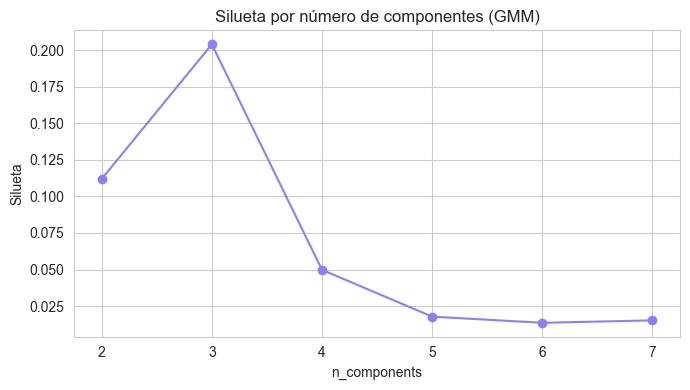

n_components con mejor silueta: 3 (silueta=0.2040)


In [18]:
sil_by_k = {}
for k in range(2, 8):
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=3).fit(X_model)
    labels = gmm.predict(X_model)
    sil_by_k[k] = silhouette_score(X_model, labels, sample_size=5000, random_state=RANDOM_STATE)

plt.figure(figsize=(7, 4))
plt.plot(list(sil_by_k.keys()), list(sil_by_k.values()), marker='o', color='#8B7FFF')
plt.xlabel('n_components'); plt.ylabel('Silueta')
plt.title('Silueta por número de componentes (GMM)')
plt.tight_layout()
plt.show()

best_gmm_k = max(sil_by_k, key=sil_by_k.get)
print(f"n_components con mejor silueta: {best_gmm_k} (silueta={sil_by_k[best_gmm_k]:.4f})")


In [19]:
gmm_final = GaussianMixture(n_components=best_gmm_k, random_state=RANDOM_STATE, n_init=3).fit(X_model)
labels_gmm = gmm_final.predict(X_model)
sil_gmm = silhouette_score(X_model, labels_gmm, sample_size=5000, random_state=RANDOM_STATE)
print(f"GMM final -> n_components={best_gmm_k} | silueta={sil_gmm:.4f}")
print(pd.Series(labels_gmm).value_counts().sort_index().rename('tamaño del clúster'))


GMM final -> n_components=3 | silueta=0.2040
0    1354
1    6490
2    4486
Name: tamaño del clúster, dtype: int64


#### Comparación de modelos


In [20]:
comparison = pd.DataFrame({
    'Modelo': ['K-Means', 'DBSCAN', 'GMM'],
    'N° clústeres': [best_k, n_clusters_db, best_gmm_k],
    'Silueta': [sil_kmeans, sil_dbscan, sil_gmm],
    '% Ruido': [0.0, round((labels_dbscan == -1).mean() * 100, 2), 0.0],
    'Balance de tamaños (min/max)': [
        round(pd.Series(labels_kmeans).value_counts().min() / pd.Series(labels_kmeans).value_counts().max(), 3),
        round(pd.Series(labels_dbscan[labels_dbscan != -1]).value_counts().min() / pd.Series(labels_dbscan[labels_dbscan != -1]).value_counts().max(), 3),
        round(pd.Series(labels_gmm).value_counts().min() / pd.Series(labels_gmm).value_counts().max(), 3),
    ]
})
comparison


,Modelo,N° clústeres,Silueta,% Ruido,Balance de tamaños (min/max)
0,K-Means,3,0.441503,0.0,0.109
1,DBSCAN,3,0.435814,12.3,0.002
2,GMM,3,0.203966,0.0,0.209


**Selección del modelo final: K-Means (k=3).**
- Mejor silueta de los tres modelos y balance de tamaños mucho mejor que DBSCAN (0.109 vs. 0.002); GMM reparte los tamaños aún más parejo (0.209), pero con silueta bastante menor (0.204).
- DBSCAN llega a una silueta casi idéntica, pero muy desbalanceado (un clúster gigante + dos minúsculos + 12% de ruido): mejor como detector de sesiones atípicas que como segmentador.
- GMM, más flexible en teoría, tiene silueta claramente menor: BIC empuja hacia componentes que ajustan mejor la densidad general, no hacia una separación más útil.

Por eso uso K-Means (k=3) para el perfilamiento de negocio en la Fase 3.

### Paso 5: Visualización de Clústeres


### Paso 4: Pipeline Final de Producción

Los pasos anteriores corrieron por separado para poder inspeccionar cada uno (varianza explicada, codo, silueta) antes de fijar hiperparámetros. Con `n_components_90` y `best_k` ya decididos, los consolido en un único `Pipeline` de Scikit-learn: el que se usaría en producción para asignar el clúster de una sesión nueva con una sola llamada.


In [21]:
pipeline_final = Pipeline([
    ('preprocesamiento', preprocessor),
    ('pca', PCA(n_components=n_components_90, random_state=RANDOM_STATE)),
    ('cluster', KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10))
])

pipeline_final.fit(df_model)
labels_pipeline = pipeline_final.named_steps['cluster'].labels_

print("Pipeline final (preprocesamiento -> PCA -> K-Means) entrenado.")
print(f"Etiquetas idénticas a las del proceso paso a paso: {(labels_pipeline == labels_kmeans).all()}")
pipeline_final


Pipeline final (preprocesamiento -> PCA -> K-Means) entrenado.
Etiquetas idénticas a las del proceso paso a paso: True


Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues',
                                                   'SpecialDay']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['VisitorType',
                                                   'Weekend'])])),
                ('pca', PCA(n_components=8, random_state=42)),
                ('cluster', KMeans(n_clusters=3, n_init=10, random_state=42))])

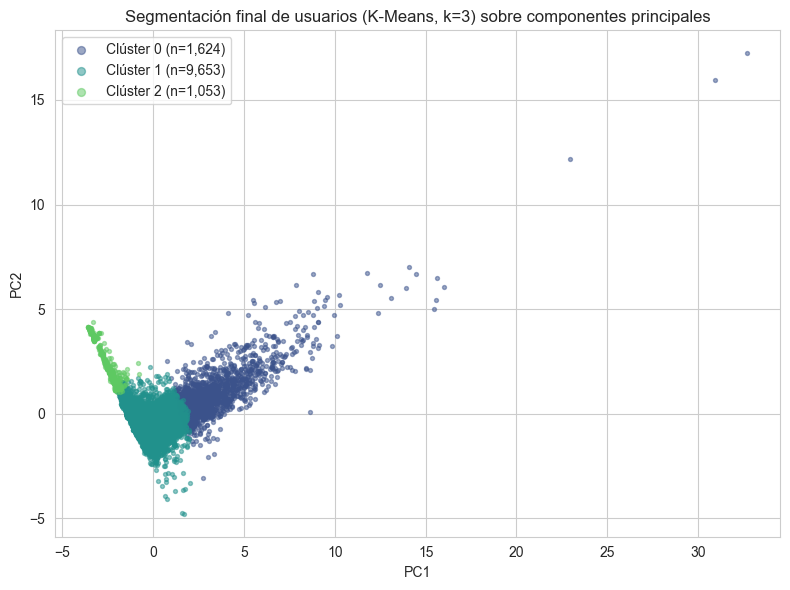

In [22]:
final_labels = labels_kmeans  # modelo ganador: K-Means

plt.figure(figsize=(8, 6))
palette = sns.color_palette('viridis', best_k)
for c in range(best_k):
    m = final_labels == c
    plt.scatter(pca_2d[m, 0], pca_2d[m, 1], s=8, alpha=0.5, color=palette[c], label=f'Clúster {c} (n={m.sum():,})')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Segmentación final de usuarios (K-Means, k=3) sobre componentes principales')
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()


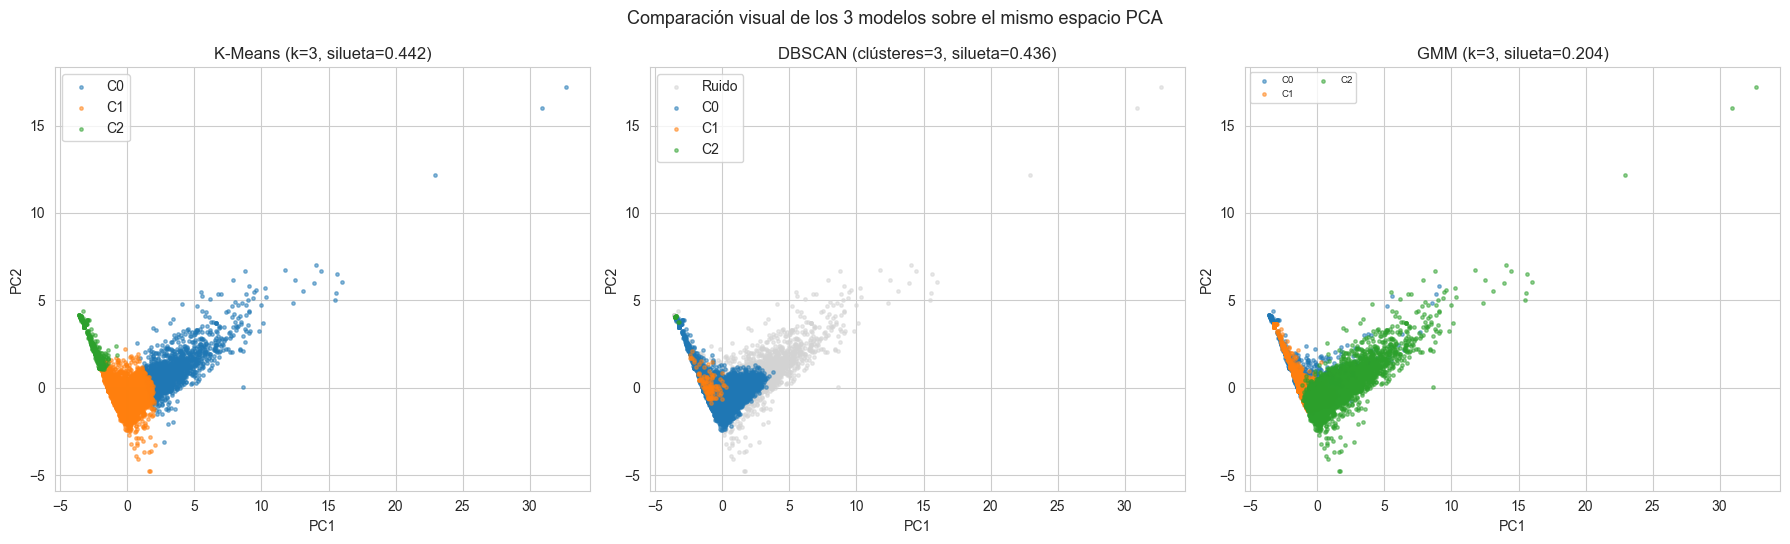

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for c in range(best_k):
    m = labels_kmeans == c
    axes[0].scatter(pca_2d[m, 0], pca_2d[m, 1], s=6, alpha=0.5, label=f'C{c}')
axes[0].set_title(f'K-Means (k={best_k}, silueta={sil_kmeans:.3f})'); axes[0].legend()

for c in sorted(set(labels_dbscan)):
    m = labels_dbscan == c
    label = 'Ruido' if c == -1 else f'C{c}'
    color = 'lightgray' if c == -1 else None
    axes[1].scatter(pca_2d[m, 0], pca_2d[m, 1], s=6, alpha=0.5, label=label, color=color)
axes[1].set_title(f'DBSCAN (clústeres={n_clusters_db}, silueta={sil_dbscan:.3f})'); axes[1].legend()

for c in range(best_gmm_k):
    m = labels_gmm == c
    axes[2].scatter(pca_2d[m, 0], pca_2d[m, 1], s=6, alpha=0.5, label=f'C{c}')
axes[2].set_title(f'GMM (k={best_gmm_k}, silueta={sil_gmm:.3f})'); axes[2].legend(fontsize=7, ncol=2)

for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.suptitle('Comparación visual de los 3 modelos sobre el mismo espacio PCA', fontsize=13)
plt.tight_layout()
plt.show()


## Fase 3: Interpretación de Perfiles y Entrega

### Paso 6: Perfilamiento (Insight Final)


In [24]:
df_profile = df.copy()
df_profile['cluster'] = labels_kmeans

profile_means = df_profile.groupby('cluster')[numeric_cols].mean().round(2).T
profile_means


cluster,0,1,2
Administrative,7.38,1.71,0.05
Administrative_Duration,307.81,51.29,1.41
Informational,2.52,0.22,0.02
Informational_Duration,213.48,8.11,0.09
ProductRelated,96.86,23.90,3.04
ProductRelated_Duration,3838.26,874.08,57.40
BounceRates,0.01,0.01,0.17
ExitRates,0.02,0.03,0.18
PageValues,9.70,5.89,0.00
SpecialDay,0.03,0.06,0.11


**Lectura rápida:** el heatmap muestra cuánto se aleja el promedio de cada clúster del promedio general, en desviaciones estándar. Rojo = por encima, azul = por debajo.


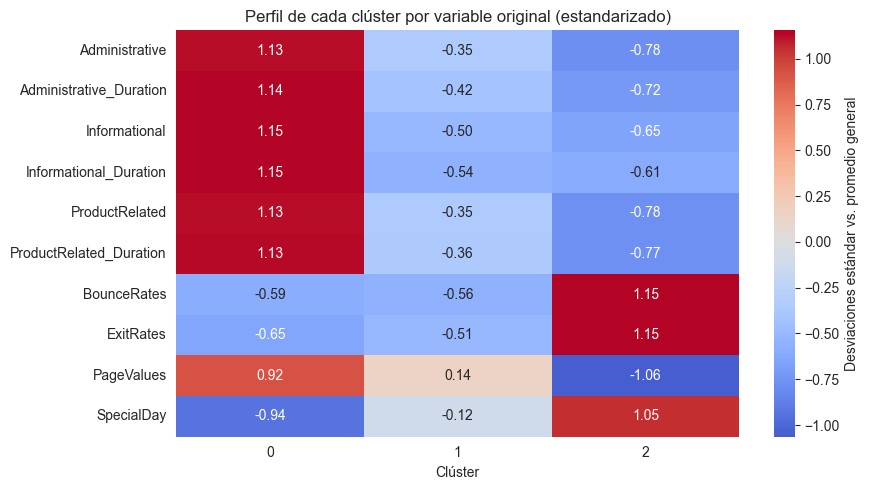

In [25]:
profile_z = df_profile.groupby('cluster')[numeric_cols].mean()
profile_z = (profile_z - profile_z.mean()) / profile_z.std()

plt.figure(figsize=(9, 5))
sns.heatmap(profile_z.T, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Desviaciones estándar vs. promedio general'})
plt.title('Perfil de cada clúster por variable original (estandarizado)')
plt.ylabel('')
plt.xlabel('Clúster')
plt.tight_layout()
plt.show()


In [26]:
summary = pd.DataFrame({
    'Tamaño': df_profile['cluster'].value_counts().sort_index(),
    '% del total': (df_profile['cluster'].value_counts(normalize=True).sort_index() * 100).round(1),
    'Tasa de conversión': df_profile.groupby('cluster')['Revenue'].mean().round(3),
    '% fin de semana': df_profile.groupby('cluster')['Weekend'].apply(lambda s: (s.astype(str) == 'True').mean()).round(3),
    '% visitante recurrente': df_profile.groupby('cluster')['VisitorType'].apply(lambda s: (s == 'Returning_Visitor').mean()).round(3),
})
summary


,Tamaño,% del total,Tasa de conversión,% fin de semana,% visitante recurrente
cluster,,,,,
0,1624,13.2,0.278,0.254,0.940
1,9653,78.3,0.150,0.236,0.831
2,1053,8.5,0.006,0.170,0.955


**Verificación de estacionalidad (`Month`):** antes de afirmar que un clúster se concentra en un mes, reviso la distribución real de `Month` por clúster (variable que no participó en el entrenamiento).


In [27]:
month_dist = pd.crosstab(df_profile['cluster'], df['Month'], normalize='index').round(3) * 100
order_meses = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
order_meses = [m for m in order_meses if m in month_dist.columns]
month_dist[order_meses]


Month,Feb,Mar,May,June,Jul,Aug,Sep,Oct,Nov,Dec
cluster,,,,,,,,,,
0,0.2,10.5,20.0,2.3,3.2,4.2,3.8,5.5,38.0,12.4
1,1.4,16.2,27.6,2.2,3.5,3.5,3.9,4.6,22.5,14.5
2,3.9,16.9,35.5,4.0,3.6,2.4,0.9,1.2,19.5,12.1


### Perfiles de Clúster

**Clúster 0 — Compradores de Alto Valor (n=1,624 · 13.2%)**
El grupo más comprometido: ~97 páginas de producto (3,838 s), el `PageValues` más alto (9.70) y las tasas de rebote/salida más bajas. Conversión del 27.8%, casi el doble del promedio global (15.5%). Se concentra en noviembre (38%), luego mayo y diciembre, señal de temporada de descuentos. 94% son recurrentes.
> *Acción:* campañas premium, acceso anticipado a promociones, fidelización.

**Clúster 1 — Navegantes Regulares (n=9,653 · 78.3%)**
El grueso del tráfico, comportamiento intermedio: ~24 páginas (874 s), `PageValues` moderado (5.89), conversión del 15.0%, cerca del promedio. Mayor proporción de visitantes nuevos (16.2%).
> *Acción:* recomendaciones personalizadas y retargeting para moverlos hacia el Clúster 0.

**Clúster 2 — Visitantes Fugaces / Alto Rebote (n=1,053 · 8.5%)**
Compromiso casi nulo: 3 páginas y 57 segundos en promedio, rebote (0.17) y salida (0.18) más altos, `PageValues` casi en cero. Conversión de apenas 0.6%, 25 veces menor que el promedio.
> *Acción:* revisar la calidad del tráfico y la landing page; no priorizar retargeting aquí.


### Conclusiones y Próximos Pasos

- El pipeline de Scikit-learn (imputación + escalado + PCA + clustering), consolidado en un único `Pipeline`, redujo 15 dimensiones a 8 componentes (92.7% de varianza) y permitió comparar los tres modelos bajo las mismas condiciones.
- K-Means (k=3): mejor combinación de silueta, balance frente a DBSCAN e interpretabilidad de negocio.
- DBSCAN: mejor como detector de anomalías que como segmentador, dada la densidad tan heterogénea del dataset.
- GMM: optimizar por BIC no garantiza clústeres separables; la silueta evitó quedarme con componentes que solo ajustan mejor la densidad.
- Próximos pasos: sumar `Month`/`TrafficType` con mejor codificación, probar HDBSCAN, y validar las acciones de marketing con una prueba A/B por segmento.

